In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Shape of the dataset: (100, 6)
Number of rows: 100
Number of columns: 6

First five rows:


,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113



Last five rows:


,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548
99,6.000000,-0.193438,-2.244792,1.930035,4.992414,-6.872850



Column names:
['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']


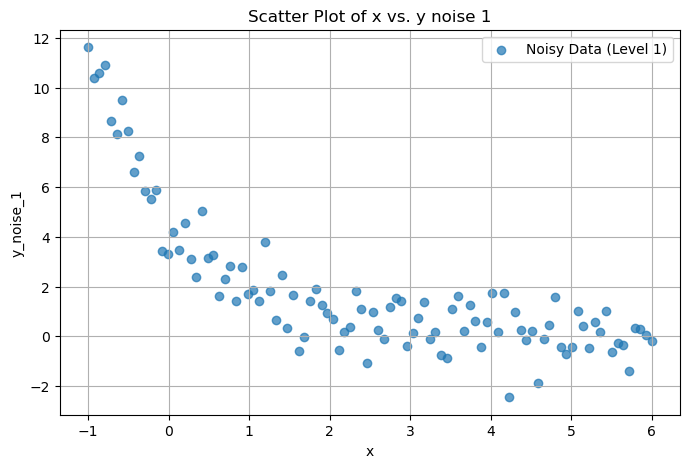

In [27]:
# Import the dataframe
df = pd.read_csv("../../course_assignments/homework9/noisy_curvefit_data.csv")

# Inspect the Data
print("Shape of the dataset:", df.shape)

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nFirst five rows:")
display(df.head())

print("\nLast five rows:")
display(df.tail())

print("\nColumn names:")
print(df.columns.tolist())

# Plot
plt.figure(figsize=(8,5))
plt.scatter(df['x'], df['y_noise_1'], label='Noisy Data (Level 1)', alpha=0.7)

plt.title("Scatter Plot of x vs. y noise 1")
plt.xlabel("x")
plt.ylabel("y_noise_1")
plt.legend()
plt.grid(True)
plt.show()

Fit: y = 4.71 * e^(-0.92 * x)


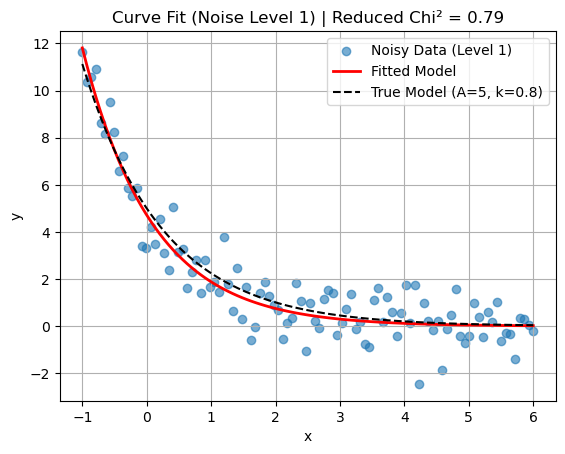

In [17]:
def model(x, A, k):
    return A * np.exp(-k * x)

#Initial guess
p0 = [1, 1]

popt, pcov = curve_fit(model, df['x'], df['y_noise_1'], p0=p0)
A_fit, k_fit = popt
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

# Calculate the fitted y values using the optimized parameters
y_fit = model(df['x'], A_fit, k_fit)

# Assuming the true parameters are A=5, k=0.8 as mentioned in the plot label
y_true = model(df['x'], 5, 0.8)  # Added this line to define y_true

residuals = df['y_noise_1'] - model(df['x'], A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(df['x']) - len(popt)
chi2_reduced = chi2 / dof

plt.scatter(df['x'], df['y_noise_1'], label='Noisy Data (Level 1)', alpha=0.6)
plt.plot(df['x'], y_fit, label='Fitted Model', linewidth=2, color='red')
plt.plot(df['x'], y_true, label='True Model (A=5, k=0.8)', linestyle='--', color='black')

plt.title(f"Curve Fit (Noise Level 1) | Reduced Chi² = {chi2_reduced:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

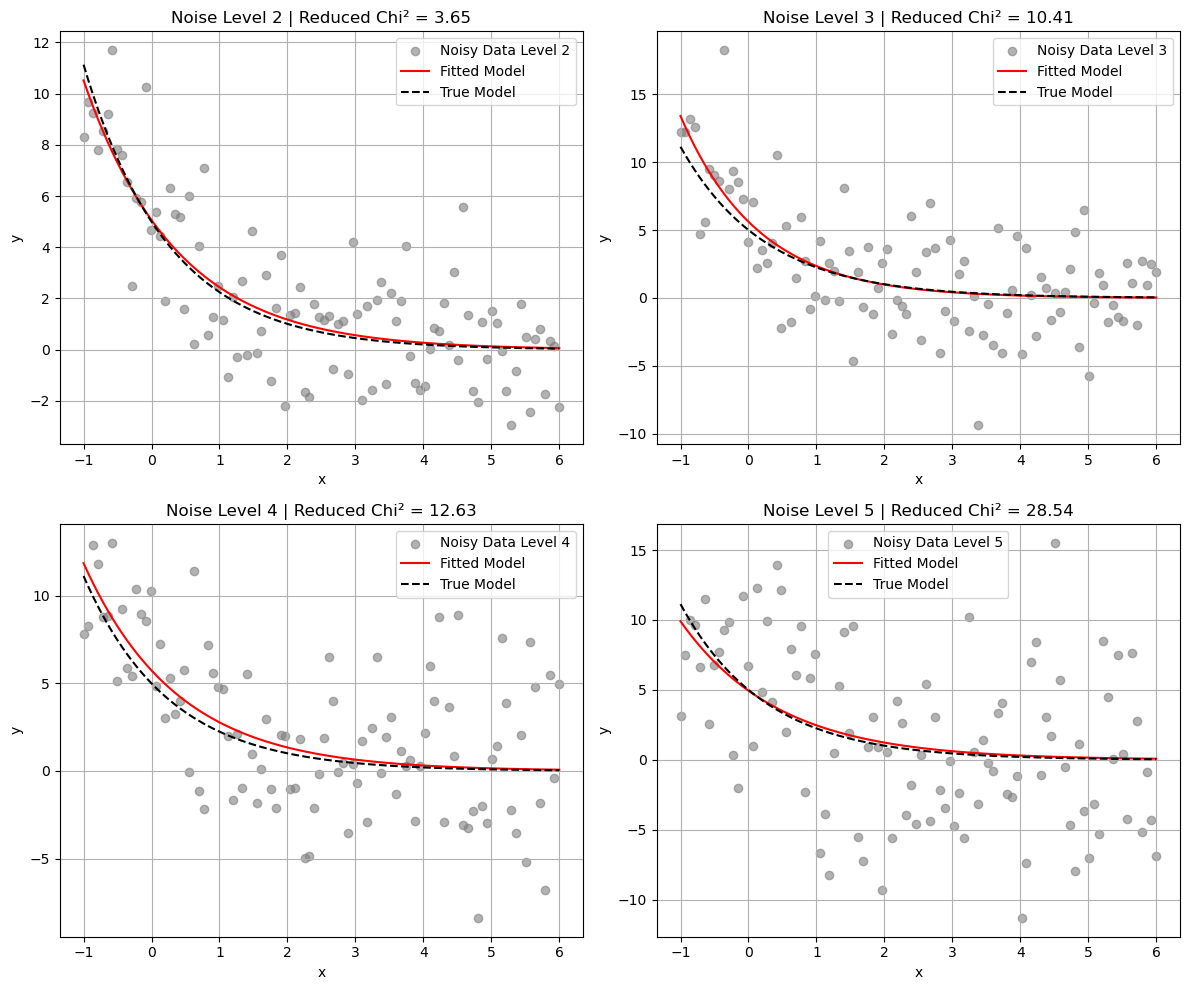

'Reduced Chi-squared increases as the noise level increases, because with more noise the residuals get larger making the fits worse and the chi-sqquared higher.'

In [26]:
def fit_model(x, y):
    p0 = [1, 1]
    # Fit model
    popt, pcov = curve_fit(model, x, y, p0=p0)
    
    # Best-fit parameters
    A_fit, k_fit = popt
    
    # Reduced chi-squared
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    
    return (A_fit, k_fit), chi2_reduced

y_columns = ['y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (ax, col) in enumerate(zip(axes, y_columns), start=2):
    y = df[col].values
    
    (A_fit, k_fit), chi2_reduced = fit_model(df['x'], y)
    
    y_fit = model(df['x'], A_fit, k_fit)
    y_true = model(df['x'], 5, 0.8)
    
    # Noisy data
    ax.scatter(df['x'], y, color='gray', alpha=0.6, label=f'Noisy Data Level {i}')
    
    # Fitted curve
    ax.plot(df['x'], y_fit, color='red', label='Fitted Model')
    
    # True model
    ax.plot(df['x'], y_true, linestyle='--', color='black', label='True Model')
    
    # Title and labels
    ax.set_title(f"Noise Level {i} | Reduced Chi² = {chi2_reduced:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

"As the noise level increases the red and black dotted lines begin to match less and less closely. This is because more noise makes the data more scattered and harder to capture the trend in the curve fitting. The whole graph and curve fit become less accurate of what is really happening."
"Reduced Chi-squared increases as the noise level increases, because with more noise the residuals get larger making the fits worse and the chi-sqquared higher."

In [31]:
# List to store results
results = []

# Include all noise levels
for i in range(1, 6):
    col = f'y_noise_{i}'
    y = df[col].values
    
    # Fit
    (A_fit, k_fit), chi2_reduced = fit_model(df['x'], y)
    
    # Append to results list
    results.append([i, A_fit, k_fit, chi2_reduced])

df_params = pd.DataFrame(results, columns=['noise_level', 'A_fit', 'k_fit', 'chi2_reduced'])
df_params
df_params.to_csv("noisy_parameters.csv", index=False)